**Import Libraries**

In [1]:
import numpy as np
import pandas as pd

**1. Upload DataSet**

In [2]:
df = pd.read_csv('/content/engineering_student_placement_dataset.csv')

**==> Preview of DataSet**

In [3]:
df.head()

,Index,IQ,CGPA,Placement
0,0,112,6.61,0
1,1,127,6.47,1
2,2,128,7.87,1
3,3,113,6.15,1
4,4,108,4.12,0


**2. Preprocessing the Data**
<br>
--> Since We don't need Index column we remove that column [Feature Engineering]

In [4]:
df = df.iloc[:,1:]
df.head()

,IQ,CGPA,Placement
0,112,6.61,0
1,127,6.47,1
2,128,7.87,1
3,113,6.15,1
4,108,4.12,0


**3. EDA**
<br>
--> We will polt the graph to identify the behaviour of dataset.

In [5]:
import matplotlib.pyplot as plt


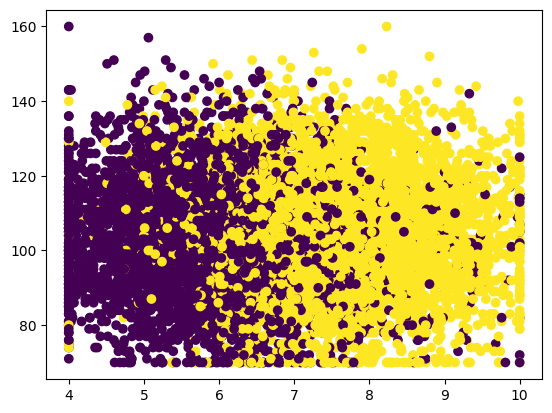

In [6]:
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])

In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
X  # X is input [IQ,CGPA]

,IQ,CGPA
0,112,6.61
1,127,6.47
2,128,7.87
3,113,6.15
4,108,4.12
...,...,...
9995,99,6.25
9996,120,9.04
9997,132,8.03
9998,86,5.99


In [9]:
y  # y is output [Placement]

,Placement
0,0
1,1
2,1
3,1
4,0
...,...
9995,0
9996,1
9997,1
9998,1


**4. Train test split**

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.03)

In [11]:
X_train

,IQ,CGPA
4209,99,7.11
600,133,6.72
6497,132,6.87
9255,129,5.73
2426,103,7.88
...,...,...
402,94,5.87
251,120,5.47
9352,127,6.70
6551,105,7.34


In [12]:
y_train

,Placement
4209,1
600,1
6497,1
9255,0
2426,1
...,...
402,0
251,0
9352,1
6551,1


In [13]:
X_test

,IQ,CGPA
6033,110,5.53
6572,100,6.04
6611,101,6.63
2998,104,6.94
4843,95,6.35
...,...,...
5665,107,8.27
5882,107,6.89
1571,110,6.91
9195,123,7.25


**5. Scale the Values**

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

**5. Train the Model**

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [17]:
clf.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [31]:
y_pred = clf.predict(X_test)
print(y_pred)

[0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 1 0
 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0
 1 1 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1 0 1
 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1
 0 1 1 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1
 1 1 1 1]


In [19]:
y_test

,Placement
6033,0
6572,1
6611,1
2998,1
4843,0
...,...
5665,1
5882,1
1571,0
9195,1


In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score(y_test,y_pred)

0.7933333333333333

**Decision Line**

In [22]:
from mlxtend.plotting import plot_decision_regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<Axes: >

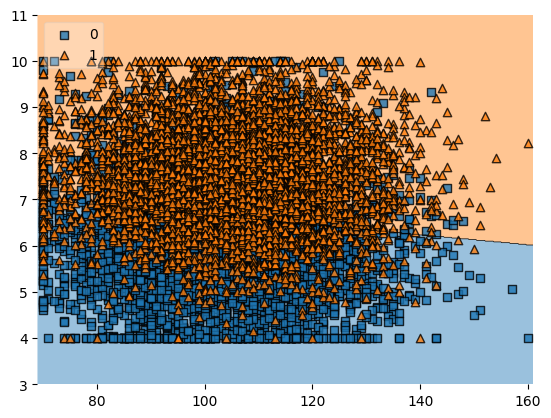

In [25]:
plot_decision_regions(X_train.values, y_train.values, clf=clf, legend=2)

**6. Getting the Model**

In [26]:
import pickle

In [27]:
pickle.dump(clf, open('model.pkl', 'wb'))

In [28]:
import os
os.listdir()

['.config',
 'engineering_student_placement_dataset.csv',
 'model.pkl',
 'sample_data']

In [29]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>